MULTIMODAL HOUSING PRICE PREDICTION

[1/7] Creating synthetic dataset...
Created 200 samples with features: ['house_id', 'bedrooms', 'bathrooms', 'sqft_living', 'lot_size', 'year_built', 'garage', 'price']

[2/7] Creating synthetic house images...
Created 200 synthetic images in 'house_images' folder

[3/7] Preparing data for training...
Train samples: 140
Validation samples: 30
Test samples: 30

[4/7] Creating datasets and dataloaders...
Batch size: 16

[5/7] Initializing multimodal model...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 129MB/s]


Model parameters: 11,284,289

[6/7] Training model...
Epoch [5/30], Train Loss: 381695907157.3333, Val Loss: 310000566272.0000
Epoch [10/30], Train Loss: 380707882780.4445, Val Loss: 309976678400.0000
Epoch [15/30], Train Loss: 381243530353.7778, Val Loss: 309832679424.0000
Epoch [20/30], Train Loss: 381258425230.2222, Val Loss: 309589245952.0000
Epoch [25/30], Train Loss: 379376846620.4445, Val Loss: 308811448320.0000
Epoch [30/30], Train Loss: 376862292195.5555, Val Loss: 307239518208.0000

[7/7] Evaluating model...
EVALUATION RESULTS
Mean Absolute Error (MAE): $504,514.72
Root Mean Square Error (RMSE): $544,769.53
MAE (% of avg price): 99.47%
RMSE (% of avg price): 107.40%

Generating plots...


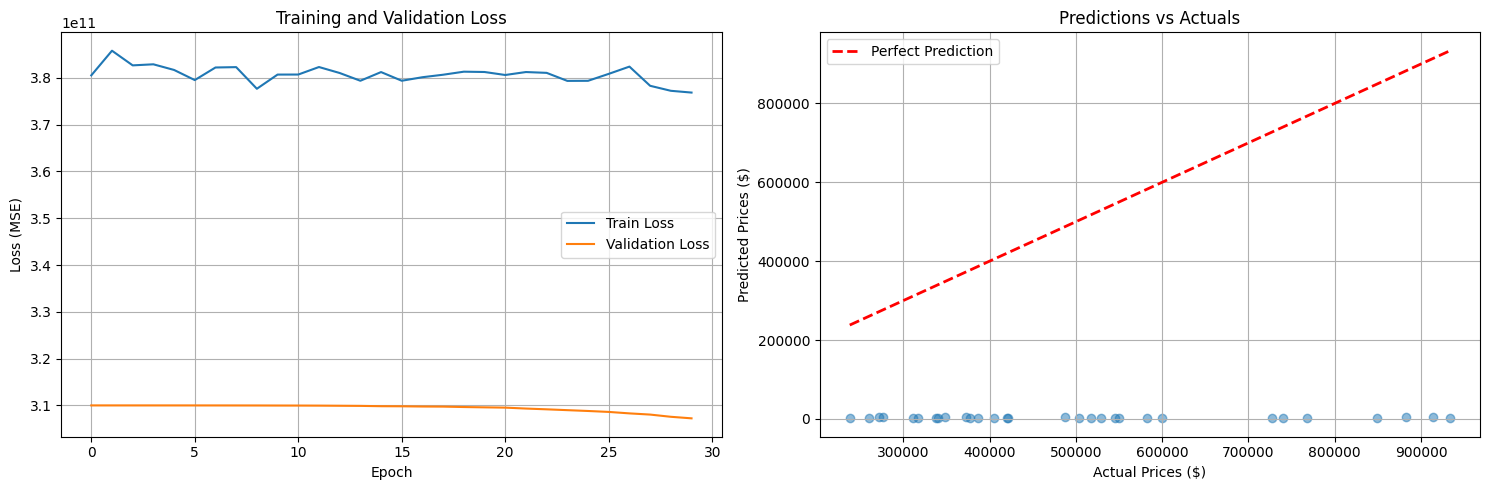


Plot saved as 'multimodal_results.png'

Saving model...
Model saved as 'multimodal_house_price_model.pth'
FEATURE ANALYSIS

Tabular Features Used:
  1. bedrooms
  2. bathrooms
  3. sqft_living
  4. lot_size
  5. year_built
  6. garage

 Task Completed Successfully!

Key Achievements:
   Used CNN to extract features from images
   Combined image features with tabular data
   Trained multimodal model for price prediction
   Evaluated using MAE and RMSE
   Saved trained model for future use


In [1]:

"""
Task 3: Multimodal Housing Price Prediction
Using Images + Tabular Data to Predict House Prices\
AI Internship - Developers Hub
Submitted by : Muhammad Zoraiz Khan
"""

# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
from PIL import Image
import os
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# PART 1: CREATE SYNTHETIC DATA FOR DEMONSTRATION

def create_synthetic_data(num_samples=100):
    """
    Create synthetic housing data for demonstration
    """
    # Create tabular data
    np.random.seed(42)

    data = {
        'house_id': range(num_samples),
        'bedrooms': np.random.randint(1, 6, num_samples),
        'bathrooms': np.random.uniform(1, 4, num_samples).round(1),
        'sqft_living': np.random.randint(800, 4000, num_samples),
        'lot_size': np.random.randint(2000, 10000, num_samples),
        'year_built': np.random.randint(1970, 2023, num_samples),
        'garage': np.random.choice([0, 1, 2], num_samples, p=[0.3, 0.5, 0.2]),
        'price': np.random.randint(150000, 800000, num_samples)  # Target variable
    }

    # Make price somewhat correlated with features
    data['price'] = (
        data['sqft_living'] * 200 +
        data['bedrooms'] * 15000 +
        data['bathrooms'] * 10000 +
        data['garage'] * 20000 +
        np.random.randint(-50000, 50000, num_samples)
    )

    df = pd.DataFrame(data)
    return df

# Create synthetic images folder
def create_synthetic_images(df, image_folder='house_images'):
    """
    Create synthetic images (simple colored rectangles) for each house
    """
    if not os.path.exists(image_folder):
        os.makedirs(image_folder)

    for idx, row in df.iterrows():
        # Create a simple image (colored rectangle based on house features)
        img = Image.new('RGB', (224, 224),
                       color=(int(row['bedrooms']*50),
                              int(row['sqft_living']/20),
                              int(row['year_built']%255)))
        img.save(f"{image_folder}/house_{idx}.jpg")

    print(f"Created {len(df)} synthetic images in '{image_folder}' folder")
# PART 2: CUSTOM DATASET CLASS
class HouseDataset(Dataset):
    """
    Custom Dataset that handles both images and tabular data
    """
    def __init__(self, df, image_folder, transform=None, tabular_features=None):
        self.df = df
        self.image_folder = image_folder
        self.transform = transform
        self.tabular_features = tabular_features or ['bedrooms', 'bathrooms',
                                                      'sqft_living', 'lot_size',
                                                      'year_built', 'garage']

        # Extract tabular data
        self.X_tabular = df[self.tabular_features].values.astype(np.float32)
        self.y = df['price'].values.astype(np.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Load image
        img_path = f"{self.image_folder}/house_{idx}.jpg"
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        # Get tabular data
        tabular = torch.tensor(self.X_tabular[idx], dtype=torch.float32)

        # Get target
        target = torch.tensor(self.y[idx], dtype=torch.float32)

        return image, tabular, target
# PART 3: MULTIMODAL MODEL
class MultimodalModel(nn.Module):
    """
    Model that combines CNN features from images with tabular data
    """
    def __init__(self, num_tabular_features, hidden_size=128):
        super(MultimodalModel, self).__init__()

        # CNN for image feature extraction (using pretrained ResNet)
        self.cnn = models.resnet18(pretrained=True)
        # Replace the final FC layer to get features instead of classification
        self.cnn.fc = nn.Identity()  # Removes the classification layer
        self.cnn_features = 512  # ResNet18 outputs 512 features

        # Fully connected layers for image features
        self.image_fc = nn.Sequential(
            nn.Linear(self.cnn_features, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        # Fully connected layers for tabular data
        self.tabular_fc = nn.Sequential(
            nn.Linear(num_tabular_features, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        # Combined layers
        self.combined = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Linear(64, 1)  # Output: predicted price
        )

    def forward(self, image, tabular):
        # Extract image features
        image_features = self.cnn(image)
        image_out = self.image_fc(image_features)

        # Process tabular data
        tabular_out = self.tabular_fc(tabular)

        # Combine both modalities
        combined = torch.cat((image_out, tabular_out), dim=1)

        # Final prediction
        output = self.combined(combined)

        return output.squeeze()
# PART 4: TRAINING FUNCTION
def train_model(model, train_loader, val_loader, epochs=20, lr=0.001):
    """
    Train the multimodal model
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0
        for images, tabular, targets in train_loader:
            images, tabular, targets = images.to(device), tabular.to(device), targets.to(device)

            optimizer.zero_grad()
            outputs = model(images, tabular)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation phase
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for images, tabular, targets in val_loader:
                images, tabular, targets = images.to(device), tabular.to(device), targets.to(device)
                outputs = model(images, tabular)
                loss = criterion(outputs, targets)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        if (epoch + 1) % 5 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}')

    return train_losses, val_losses

# PART 5: EVALUATION FUNCTION
def evaluate_model(model, test_loader):
    """
    Evaluate model using MAE and RMSE
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()

    predictions = []
    actuals = []

    with torch.no_grad():
        for images, tabular, targets in test_loader:
            images, tabular = images.to(device), tabular.to(device)
            outputs = model(images, tabular)

            predictions.extend(outputs.cpu().numpy())
            actuals.extend(targets.numpy())

    predictions = np.array(predictions)
    actuals = np.array(actuals)

    # Calculate metrics
    mae = mean_absolute_error(actuals, predictions)
    rmse = np.sqrt(mean_squared_error(actuals, predictions))

    print("EVALUATION RESULTS")
    print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
    print(f"Root Mean Square Error (RMSE): ${rmse:,.2f}")

    # Calculate percentage errors
    mae_percentage = (mae / actuals.mean()) * 100
    rmse_percentage = (rmse / actuals.mean()) * 100
    print(f"MAE (% of avg price): {mae_percentage:.2f}%")
    print(f"RMSE (% of avg price): {rmse_percentage:.2f}%")

    return predictions, actuals

# PART 6: PLOTTING RESULTS
def plot_results(train_losses, val_losses, predictions, actuals):
    """
    Plot training curves and prediction results
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Plot 1: Training and Validation Loss
    axes[0].plot(train_losses, label='Train Loss')
    axes[0].plot(val_losses, label='Validation Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss (MSE)')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True)

    # Plot 2: Predictions vs Actuals
    axes[1].scatter(actuals, predictions, alpha=0.5)
    axes[1].plot([actuals.min(), actuals.max()],
                 [actuals.min(), actuals.max()],
                 'r--', lw=2, label='Perfect Prediction')
    axes[1].set_xlabel('Actual Prices ($)')
    axes[1].set_ylabel('Predicted Prices ($)')
    axes[1].set_title('Predictions vs Actuals')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig('multimodal_results.png', dpi=150)
    plt.show()
    print("\nPlot saved as 'multimodal_results.png'")
# MAIN EXECUTION
def main():
    print("MULTIMODAL HOUSING PRICE PREDICTION")

    # Step 1: Create synthetic data (replace with your actual data)
    print("\n[1/7] Creating synthetic dataset...")
    df = create_synthetic_data(num_samples=200)
    print(f"Created {len(df)} samples with features: {list(df.columns)}")

    # Step 2: Create synthetic images
    print("\n[2/7] Creating synthetic house images...")
    create_synthetic_images(df, image_folder='house_images')

    # Step 3: Prepare data
    print("\n[3/7] Preparing data for training...")
    # Split data
    train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)
    val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

    print(f"Train samples: {len(train_df)}")
    print(f"Validation samples: {len(val_df)}")
    print(f"Test samples: {len(test_df)}")

    # Step 4: Scale tabular features
    tabular_features = ['bedrooms', 'bathrooms', 'sqft_living',
                        'lot_size', 'year_built', 'garage']

    scaler = StandardScaler()
    train_df_scaled = train_df.copy()
    val_df_scaled = val_df.copy()
    test_df_scaled = test_df.copy()

    train_df_scaled[tabular_features] = scaler.fit_transform(train_df[tabular_features])
    val_df_scaled[tabular_features] = scaler.transform(val_df[tabular_features])
    test_df_scaled[tabular_features] = scaler.transform(test_df[tabular_features])

    # Step 5: Create datasets and dataloaders
    print("\n[4/7] Creating datasets and dataloaders...")

    # Define image transforms
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])

    # Create datasets
    train_dataset = HouseDataset(train_df_scaled, 'house_images', transform, tabular_features)
    val_dataset = HouseDataset(val_df_scaled, 'house_images', transform, tabular_features)
    test_dataset = HouseDataset(test_df_scaled, 'house_images', transform, tabular_features)

    # Create dataloaders
    batch_size = 16
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    print(f"Batch size: {batch_size}")

    # Step 6: Initialize and train model
    print("\n[5/7] Initializing multimodal model...")
    model = MultimodalModel(num_tabular_features=len(tabular_features), hidden_size=128)
    print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

    print("\n[6/7] Training model...")
    train_losses, val_losses = train_model(model, train_loader, val_loader, epochs=30, lr=0.0001)

    # Step 7: Evaluate model
    print("\n[7/7] Evaluating model...")
    predictions, actuals = evaluate_model(model, test_loader)

    # Step 8: Plot results
    print("\nGenerating plots...")
    plot_results(train_losses, val_losses, predictions, actuals)

    # Step 9: Save model
    print("\nSaving model...")
    torch.save({
        'model_state_dict': model.state_dict(),
        'scaler': scaler,
        'tabular_features': tabular_features
    }, 'multimodal_house_price_model.pth')
    print("Model saved as 'multimodal_house_price_model.pth'")

    # Step 10: Feature importance analysis
    print("FEATURE ANALYSIS")
    print("\nTabular Features Used:")
    for i, feature in enumerate(tabular_features):
        print(f"  {i+1}. {feature}")


# Run the main function
if __name__ == "__main__":
    main()
    print("\n Task Completed Successfully!")
    print("\nKey Achievements:")
    print("   Used CNN to extract features from images")
    print("   Combined image features with tabular data")
    print("   Trained multimodal model for price prediction")
    print("   Evaluated using MAE and RMSE")
    print("   Saved trained model for future use")